# CRISP-DM on the Palmer Penguins data

This notebook walks one small question through all six phases of **CRISP-DM**. The dataset is the
Palmer Penguins table: body measurements for three penguin species across three islands. The point
is the *process*, not the model, so each phase explains why it exists before showing any code.

## Learning objectives

By the end of this notebook you should be able to:

- Move a question through business understanding, data understanding, data preparation,
  modelling, evaluation, and deployment.
- Inspect a real table for shape, types, missing values, and plausible ranges.
- Prepare only the columns the question needs and account for dropped rows.
- Fit an interpretable decision tree with a fixed seed and evaluate it on held-out data.
- Compare a model's accuracy with a majority-class baseline and read a confusion matrix.
- Discuss honestly what a deployed version of the result could and could not do.

## Concept

**CRISP-DM** is a six-phase checklist for data projects. The phases are:

1. **Business understanding** — turn a wish into a measurable question with a success criterion.
2. **Data understanding** — inspect the table before trusting it.
3. **Data preparation** — build the table the model needs; record what was dropped.
4. **Modelling** — fit a method that suits the question and the audience.
5. **Evaluation** — judge on unseen data against the original goal.
6. **Deployment** — say how the result would be used, monitored, and retrained.

The phases feed back into one another. If the data cannot answer the question, return to phase 1;
if preparation introduces problems, return to phase 2. Treat the list as a set of concerns to
cover, not a single pass.

## Worked example

### Phase 1 — Business understanding

**The question.** Can a penguin's species be recovered from its four body measurements?

**Why it matters.** Field researchers sometimes record measurements before a species is confirmed.
A model that predicts species from measurements could flag records whose label looks inconsistent,
so the record can be checked by a human.

**Success criteria.** The model must (a) beat the majority-class baseline clearly, (b) be
explainable to a field researcher, and (c) have mistakes we can describe. This is a three-class
**classification** problem.

### Phase 2 — Data understanding

We load the cached table with the shared helper (which raises a clear error if the file is
missing) and look at its shape, columns, types, missing values, and ranges.

In [1]:
from ds_practice import load_penguins, set_seed, set_theme

set_seed(42)
set_theme()

df = load_penguins()
print("shape:", df.shape)
print("\ncolumns:", list(df.columns))
df.head()

shape: (344, 8)

columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [2]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

In [3]:
df.isna().sum().sort_values(ascending=False)

sex                  11
bill_depth_mm         2
flipper_length_mm     2
bill_length_mm        2
body_mass_g           2
island                0
species               0
year                  0
dtype: int64

In [4]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
df[features].describe().round(1)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.0,342.0,342.0,342.0
mean,43.9,17.2,200.9,4201.8
std,5.5,2.0,14.1,802.0
min,32.1,13.1,172.0,2700.0
25%,39.2,15.6,190.0,3550.0
50%,44.4,17.3,197.0,4050.0
75%,48.5,18.7,213.0,4750.0
max,59.6,21.5,231.0,6300.0


The four measurements are numeric; `species`, `island`, and `sex` are categorical. A few rows have
missing values in the numeric columns. Body mass has a wide range, which is useful context if a
later method is sensitive to scale. We plot body mass and one bill measurement to see the shape of
each distribution.

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Body mass'}, xlabel='body mass (g)', ylabel='Count'>)

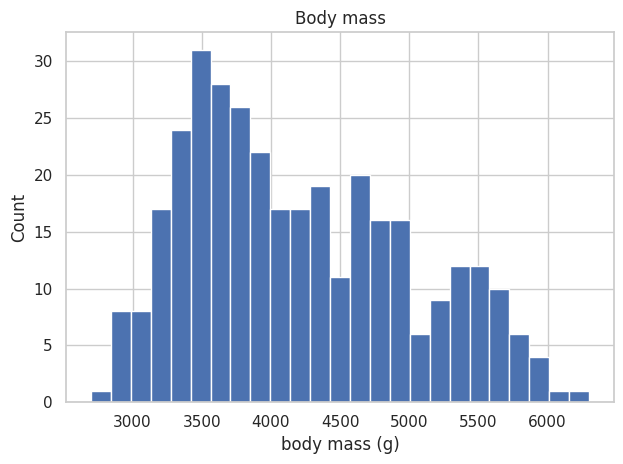

In [5]:
from ds_practice import boxplot, histogram

histogram(df["body_mass_g"].dropna(), bins=25,
          title="Body mass", xlabel="body mass (g)")

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Flipper length by species'}, ylabel='flipper length (mm)'>)

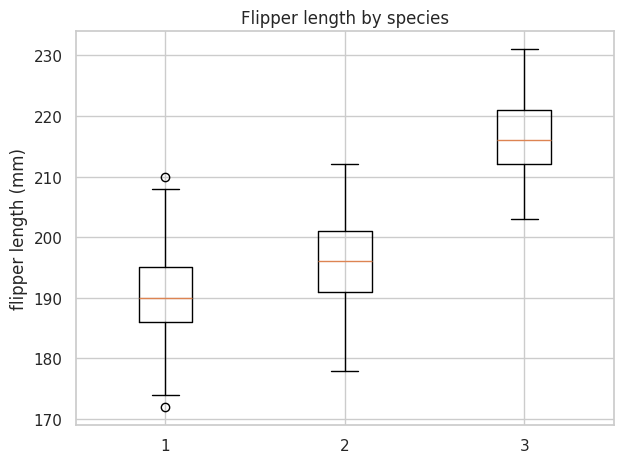

In [6]:
boxplot([df.loc[df["species"] == s, "flipper_length_mm"].dropna()
         for s in sorted(df["species"].dropna().unique())],
        title="Flipper length by species", ylabel="flipper length (mm)")

### Phase 3 — Data preparation

Preparation follows the question. We need the four measurements as features and `species` as the
target, so rows missing any of those five columns are removed. Crucially, we **count** what we
remove; quietly dropping rows hides a data-quality problem.

In [7]:
model_df = df[["species", *features]].dropna().reset_index(drop=True)

dropped = len(df) - len(model_df)
print(f"kept {len(model_df)} of {len(df)} rows ({dropped} dropped)")
model_df["species"].value_counts()

kept 342 of 344 rows (2 dropped)


species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

The classes are reasonably balanced, so a majority-class baseline will sit near one third and any
useful model must clear it comfortably.

### Phase 4 — Modelling

We split the prepared table into a training set and a held-out test set, then fit a **decision
tree**. A tree is chosen deliberately: it is interpretable, and its rules can be read by a domain
expert. Both the split and the model use the seed `42`, so the result is reproducible.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

X = model_df[features].to_numpy()
y = model_df["species"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

print("training rows:", len(X_train), "| test rows:", len(X_test))
print()
print(export_text(tree, feature_names=features))

training rows: 256 | test rows: 86

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.55
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  17.55
|   |   |--- class: Chinstrap



The printed rules are the model. A field researcher can follow them without knowing anything about
decision trees, which is exactly why this method was selected over a more accurate black box.

### Phase 5 — Evaluation

Training accuracy flatters every model, so we judge on the test set. We compare against a
majority-class **baseline** and inspect where the mistakes fall.

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from ds_practice import classification_metrics

pred = tree.predict(X_test)
baseline = np.full_like(y_test, model_df["species"].mode()[0])

print("baseline accuracy:", round(accuracy_score(y_test, baseline), 3))
print("tree accuracy:   ", round(accuracy_score(y_test, pred), 3))
print()
print(classification_metrics(y_test, pred))
print()
print(classification_report(y_test, pred, zero_division=0))
print("confusion matrix (rows = truth, columns = predicted):")
print(confusion_matrix(y_test, pred))

baseline accuracy: 0.442
tree accuracy:    0.988

{'accuracy': 0.9883720930232558, 'precision': 0.9886702444841979, 'recall': 0.9883720930232558, 'f1': 0.9882714185039766}

              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.99        38
   Chinstrap       1.00      0.94      0.97        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           0.99        86
   macro avg       0.99      0.98      0.99        86
weighted avg       0.99      0.99      0.99        86

confusion matrix (rows = truth, columns = predicted):
[[38  0  0]
 [ 1 16  0]
 [ 0  0 31]]


Even at a shallow depth the tree clears the baseline comfortably. The mistakes that remain fall
between the two species whose bill measurements overlap; the confusion matrix shows this directly,
which a single accuracy number would hide.

**Back to the business question.** A tree like this could flag measurements that look unusual for a
claimed label, but it is not proof and must not replace expert verification.

### Phase 6 — Deployment

"Deployment" here means describing how the result would be used, not shipping a service. A field
tool would:

1. score new measurements,
2. show the predicted species **with a confidence**, and
3. route low-confidence cases to a human reviewer.

Over time, predictions that turn out wrong should be logged with the corrected label and used to
retrain the model. That feedback loop is what keeps the tool useful as conditions change.

## Exercises

1. Restate the question as a *regression* task by predicting `body_mass_g` from the other three
   measurements (and species, if you wish). Which CRISP-DM phase changes most, and how would the
   success criterion change?
2. Instead of dropping rows with missing measurements, impute each missing numeric value with the
   **median of its species**. Re-run the preparation and model, and report whether held-out
   accuracy changes. In two or three sentences, argue for or against imputation on this dataset.
3. Increase the tree's `max_depth` from `2` to `8`, evaluate it, and record the training and test
   accuracy. Explain what the gap between them tells you, and choose the depth you would hand to a
   field researcher.

## Limitations

- The dataset is small, balanced, and clean, so it under-states how much work preparation is on a
  real project.
- A single train/test split is noisy; a careful study would use cross-validation and report a
  range rather than one number.
- The tree is chosen for explainability, not for maximum accuracy, and a deeper model would score
  higher on this table at the cost of being harder to read.
- Deployment is discussed, not built: there is no service, API, or monitoring here, and the model
  describes these populations only.